# Proyecto 3 - Clustering de clientes con K-Means

## Integrantes
- Daniel Fernando Salgado Santamaría
- Jairo Wladimir Jhayya Perlaza
- Luis Gabriel Salgado Santamaría
- Oscar Paul Naranjo Castro

**Fecha:** 2026-05-13  
**Notebook:** 03-jj-clustering-clientes.ipynb

## Objetivo
Aplicar clustering no supervisado sobre la tabla `customer_features.csv` para identificar segmentos de clientes con comportamientos similares.

Se evaluará el número adecuado de clusters mediante:
- método del codo,
- silhouette score,
- análisis descriptivo de los segmentos generados.

In [31]:
# Importa librerías necesarias para rutas, análisis, visualización y clustering.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [32]:
# Configura opciones de visualización de pandas.
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [33]:
# Configura estilo visual global del notebook.
sns.set_theme(style="whitegrid", context="talk")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 400
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

In [34]:
# Define una paleta viva pero profesional para mantener uniformidad visual.
PALETTE_VIVID = [
    "#0F766E",
    "#2563EB",
    "#DC2626",
    "#F59E0B",
    "#7C3AED",
    "#059669",
    "#EA580C",
    "#DB2777",
    "#0891B2",
    "#65A30D",
]

In [35]:
# Define rutas del proyecto y carpetas de salida.
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

CLUSTER_FIG_DIR = FIGURES_DIR / "clustering_clientes"
CLUSTER_FIG_DIR.mkdir(parents=True, exist_ok=True)

for path in [PROCESSED_DIR, FIGURES_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("CLUSTER_FIG_DIR:", CLUSTER_FIG_DIR)

PROJECT_ROOT: G:\ProyectosPython\proyecto3\desarrollo3
PROCESSED_DIR: G:\ProyectosPython\proyecto3\desarrollo3\data\processed
CLUSTER_FIG_DIR: G:\ProyectosPython\proyecto3\desarrollo3\reports\figures\clustering_clientes


In [36]:
# Define función para guardar figuras en alta resolución.
def save_plot(filename):
    plt.savefig(CLUSTER_FIG_DIR / filename, dpi=400, bbox_inches="tight", facecolor="white")

In [37]:
# Define función auxiliar para etiquetar barras verticales con valores o porcentajes.
def annotate_bars(ax, fmt="{:.2f}", suffix="", fontsize=10, weight="bold"):
    for patch in ax.patches:
        height = patch.get_height()
        if pd.notnull(height):
            x = patch.get_x() + patch.get_width() / 2
            ax.annotate(
                fmt.format(height) + suffix,
                (x, height),
                ha="center",
                va="bottom",
                fontsize=fontsize,
                fontweight=weight,
                xytext=(0, 6),
                textcoords="offset points"
            )

## Carga de datos

Se carga la tabla consolidada de clientes generada en el notebook anterior.

In [38]:
# Carga la tabla de características consolidadas de clientes.
customer_features = pd.read_csv(PROCESSED_DIR / "customer_features.csv")

print(customer_features.shape)
customer_features.head()

(20000, 10)


,customer_id,country,age,signup_date,marketing_opt_in,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,1,JP,71,2020-09-04,True,5.00,2.00,115.39,57.69,1.00
1,2,IN,26,2020-04-05,False,3.00,2.00,68.52,34.26,0.00
2,3,BR,21,2023-08-31,True,5.00,1.00,66.72,66.72,0.00
3,4,FR,63,2022-06-30,True,9.00,2.00,279.86,139.93,0.00
4,5,BR,19,2022-07-22,True,9.00,3.00,271.29,90.43,4.00


In [39]:
# Muestra la estructura general de las variables disponibles.
customer_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          20000 non-null  int64  
 1   country              20000 non-null  str    
 2   age                  20000 non-null  int64  
 3   signup_date          20000 non-null  str    
 4   marketing_opt_in     20000 non-null  bool   
 5   n_sessions           20000 non-null  float64
 6   n_orders             20000 non-null  float64
 7   gross_revenue_usd    20000 non-null  float64
 8   avg_order_value_usd  20000 non-null  float64
 9   n_reviews            20000 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(2)
memory usage: 1.4 MB


## Selección de variables para clustering

Se seleccionan variables numéricas asociadas al comportamiento del cliente para evitar mezclar directamente variables categóricas en K-Means.

In [40]:
# Define las variables numéricas que se usarán en el clustering.
cluster_features = [
    "age",
    "n_sessions",
    "n_orders",
    "gross_revenue_usd",
    "avg_order_value_usd",
    "n_reviews"
]

X = customer_features[cluster_features].copy()

print(X.head())

   age  n_sessions  n_orders  gross_revenue_usd  avg_order_value_usd  n_reviews
0   71        5.00      2.00             115.39                57.69       1.00
1   26        3.00      2.00              68.52                34.26       0.00
2   21        5.00      1.00              66.72                66.72       0.00
3   63        9.00      2.00             279.86               139.93       0.00
4   19        9.00      3.00             271.29                90.43       4.00


In [41]:
# Revisa nulos antes del escalado.
print(X.isnull().sum())

age                    0
n_sessions             0
n_orders               0
gross_revenue_usd      0
avg_order_value_usd    0
n_reviews              0
dtype: int64


In [42]:
# Escala las variables para que todas contribuyan de forma comparable al algoritmo K-Means.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape escalado:", X_scaled.shape)

Shape escalado: (20000, 6)


## Evaluación del número de clusters

Se prueba una secuencia de valores de k para analizar:
- inercia (método del codo),
- silhouette score.

In [43]:
# Evalúa varios valores de k con K-Means usando inercia y silhouette score.
k_values = list(range(2, 11))
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

evaluation_df = pd.DataFrame({
    "k": k_values,
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

evaluation_df

,k,inertia,silhouette_score
0,2,"86,894.49",0.30
1,3,"76,032.62",0.26
2,4,"66,362.27",0.23
3,5,"57,772.15",0.22
4,6,"53,163.20",0.20
5,7,"49,236.69",0.19
6,8,"46,345.51",0.20
7,9,"43,706.24",0.20
8,10,"41,677.03",0.20


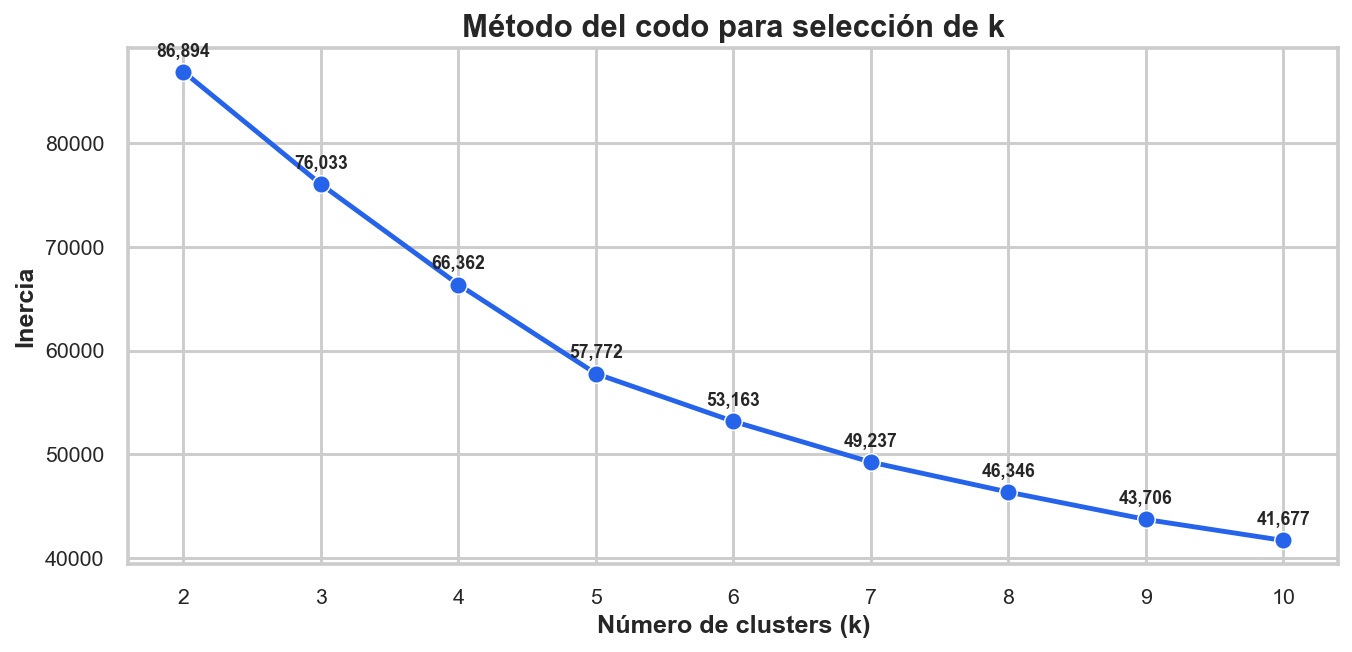

In [44]:
# Grafica la curva del codo e incluye la inercia exacta sobre cada punto.
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=evaluation_df,
    x="k",
    y="inertia",
    marker="o",
    linewidth=2.5,
    color=PALETTE_VIVID[1]
)

for x_val, y_val in zip(evaluation_df["k"], evaluation_df["inertia"]):
    ax.annotate(
        f"{y_val:,.0f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Método del codo para selección de k")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.tight_layout()
save_plot("metodo_codo_kmeans.png")
plt.show()

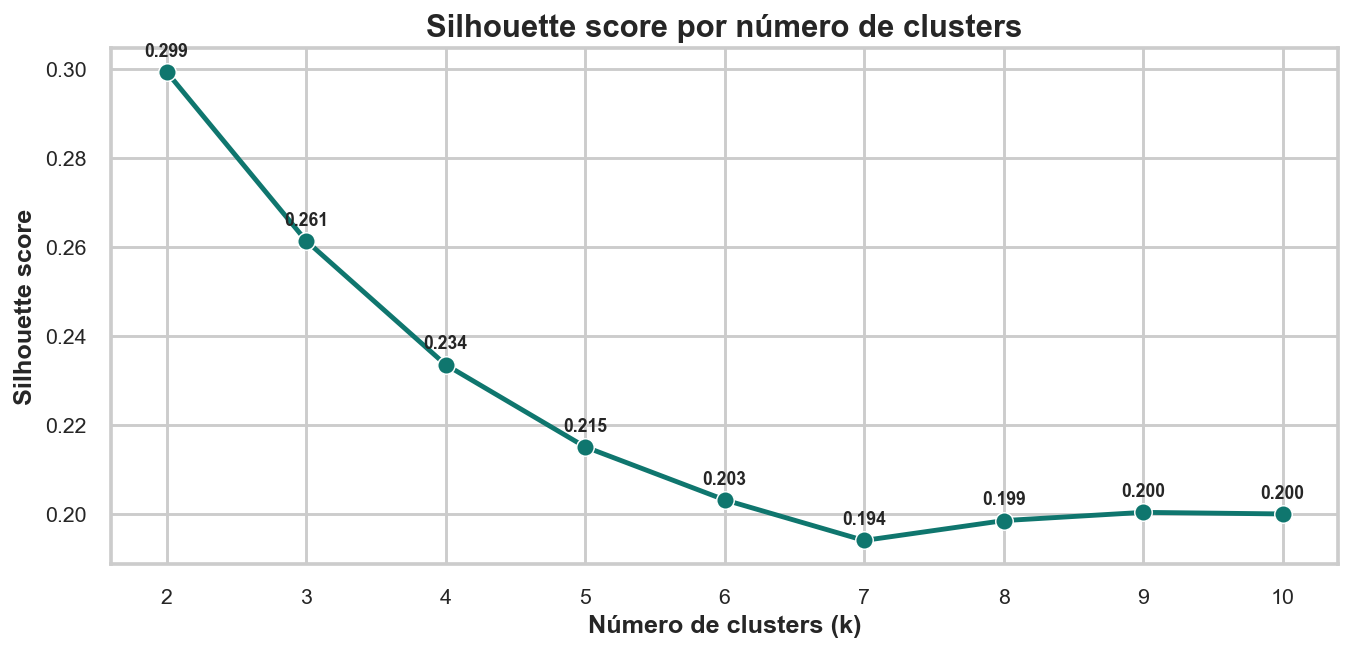

In [45]:
# Grafica el silhouette score e incluye el valor exacto sobre cada punto.
plt.figure(figsize=(10, 5))

ax = sns.lineplot(
    data=evaluation_df,
    x="k",
    y="silhouette_score",
    marker="o",
    linewidth=2.5,
    color=PALETTE_VIVID[0]
)

for x_val, y_val in zip(evaluation_df["k"], evaluation_df["silhouette_score"]):
    ax.annotate(
        f"{y_val:.3f}",
        (x_val, y_val),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Silhouette score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
save_plot("silhouette_score_kmeans.png")
plt.show()

## Selección del modelo final

Con base en los resultados del codo y silhouette, se elige un valor final de k para construir la segmentación.

In [46]:
# Selecciona el mejor k según el máximo silhouette score.
best_k = evaluation_df.loc[evaluation_df["silhouette_score"].idxmax(), "k"]
best_k = int(best_k)

print(f"Mejor número de clusters según silhouette score: {best_k}")

Mejor número de clusters según silhouette score: 2


In [47]:
# Entrena el modelo final K-Means con el número de clusters seleccionado.
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
customer_features["cluster"] = kmeans_final.fit_predict(X_scaled)

customer_features[["customer_id", "cluster"]].head()

,customer_id,cluster
0,1,1
1,2,1
2,3,1
3,4,0
4,5,0


In [48]:
# Calcula el tamaño de cada cluster y su porcentaje respecto al total de clientes.
cluster_sizes = (
    customer_features["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="customers_count")
)

cluster_sizes["percentage"] = (
    cluster_sizes["customers_count"] / cluster_sizes["customers_count"].sum() * 100
).round(2)

cluster_sizes

,cluster,customers_count,percentage
0,0,7041,35.20
1,1,12959,64.80


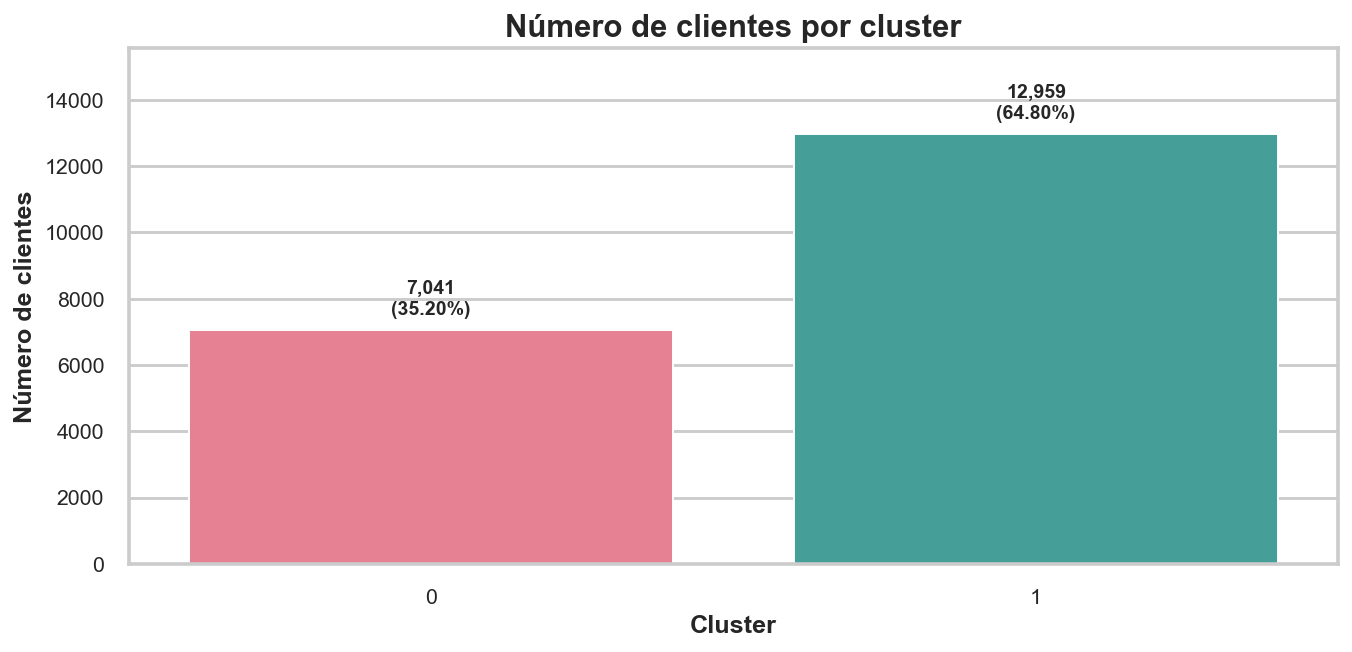

In [49]:
# Grafica el número de clientes por cluster e incluye cantidad y porcentaje en cada barra.
plt.figure(figsize=(10, 5))

palette_clusters = sns.color_palette("husl", n_colors=len(cluster_sizes))

ax = sns.barplot(
    data=cluster_sizes,
    x="cluster",
    y="customers_count",
    hue="cluster",
    dodge=False,
    legend=False,
    palette=palette_clusters,
    edgecolor="white",
    linewidth=1
)

for i, patch in enumerate(ax.patches):
    height = patch.get_height()
    pct = cluster_sizes.loc[i, "percentage"]
    ax.annotate(
        f"{height:,.0f}\n({pct:.2f}%)",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points"
    )

plt.title("Número de clientes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.ylim(0, cluster_sizes["customers_count"].max() * 1.20)
plt.tight_layout()
save_plot("tamano_clusters.png")
plt.show()

## Perfilamiento de clusters

Se calcula el promedio de las variables numéricas en cada cluster para interpretar el comportamiento característico de cada segmento.

In [50]:
# Calcula el perfil promedio de cada cluster en variables numéricas clave.
cluster_profile = (
    customer_features
    .groupby("cluster")[cluster_features]
    .mean()
    .round(2)
    .reset_index()
)

cluster_profile

,cluster,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,0,46.97,7.65,2.86,476.67,193.40,1.21
1,1,46.23,5.10,1.04,87.74,63.35,0.18


In [51]:
# Guarda la tabla descriptiva de clusters para análisis posterior.
cluster_profile_output = TABLES_DIR / "cluster_profile_kmeans.csv"
cluster_profile.to_csv(cluster_profile_output, index=False)

print(f"Tabla guardada en: {cluster_profile_output}")

Tabla guardada en: G:\ProyectosPython\proyecto3\desarrollo3\reports\tables\cluster_profile_kmeans.csv


In [52]:
# Convierte la tabla de perfil a formato largo para construir un gráfico comparativo.
cluster_profile_long = cluster_profile.melt(
    id_vars="cluster",
    var_name="metric",
    value_name="mean_value"
)

cluster_profile_long.head()

,cluster,metric,mean_value
0,0,age,46.97
1,1,age,46.23
2,0,n_sessions,7.65
3,1,n_sessions,5.10
4,0,n_orders,2.86


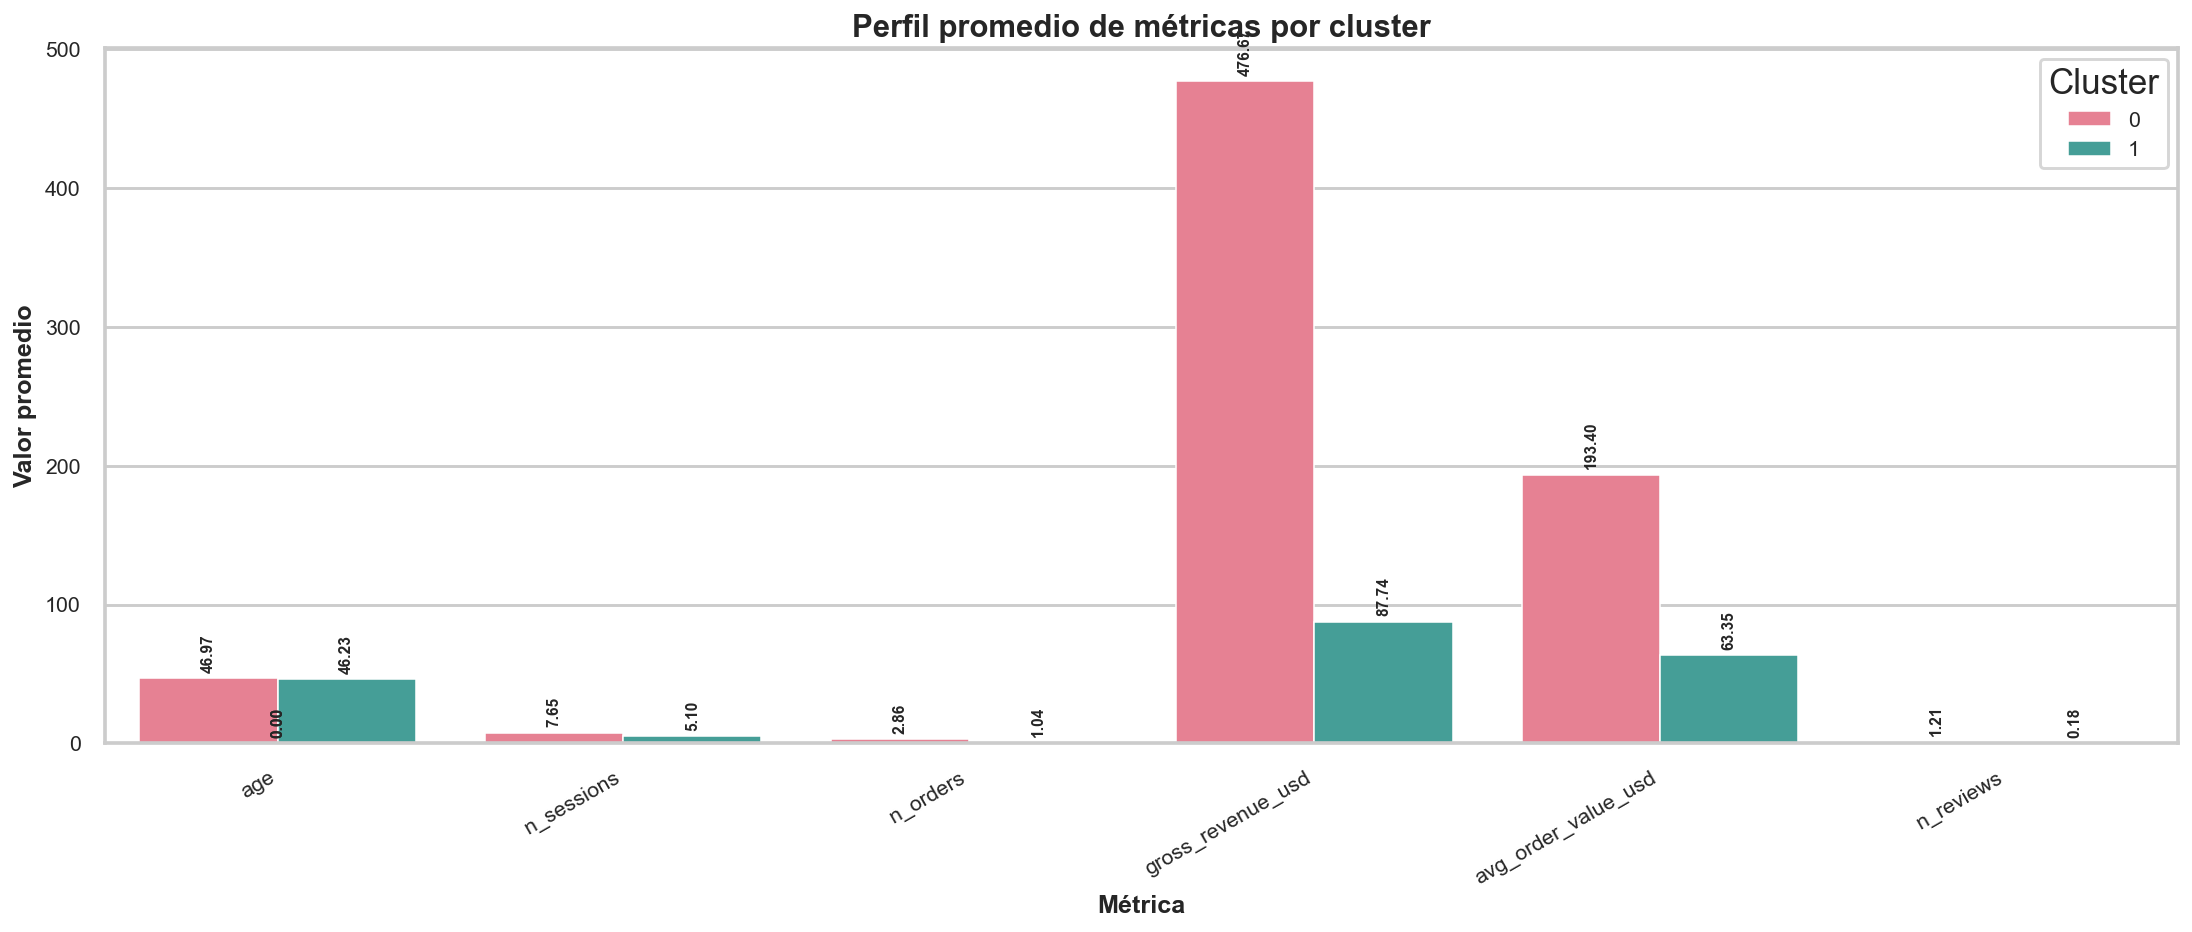

In [53]:
# Grafica el promedio de cada métrica por cluster y coloca el valor exacto sobre cada barra.
plt.figure(figsize=(16, 7))

ax = sns.barplot(
    data=cluster_profile_long,
    x="metric",
    y="mean_value",
    hue="cluster",
    palette=palette_clusters,
    edgecolor="white",
    linewidth=0.8
)

for patch in ax.patches:
    height = patch.get_height()
    if pd.notnull(height) and np.isfinite(height):
        ax.annotate(
            f"{height:.2f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            rotation=90,
            xytext=(0, 3),
            textcoords="offset points"
        )

plt.title("Perfil promedio de métricas por cluster")
plt.xlabel("Métrica")
plt.ylabel("Valor promedio")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("perfil_promedio_clusters.png")
plt.show()

In [54]:
# Construye una tabla resumida con tamaño y perfil promedio de cada cluster.
cluster_summary = cluster_sizes.merge(cluster_profile, on="cluster", how="left")
cluster_summary

,cluster,customers_count,percentage,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,0,7041,35.20,46.97,7.65,2.86,476.67,193.40,1.21
1,1,12959,64.80,46.23,5.10,1.04,87.74,63.35,0.18


In [55]:
# Guarda el resumen final de clusters.
cluster_summary_output = PROCESSED_DIR / "customer_clusters_kmeans.csv"
cluster_summary.to_csv(cluster_summary_output, index=False)

print(f"Resumen final guardado en: {cluster_summary_output}")

Resumen final guardado en: G:\ProyectosPython\proyecto3\desarrollo3\data\processed\customer_clusters_kmeans.csv


## Visualización bidimensional de clusters

Se proyecta el comportamiento de los clientes en variables de negocio interpretables para observar la separación entre clusters.

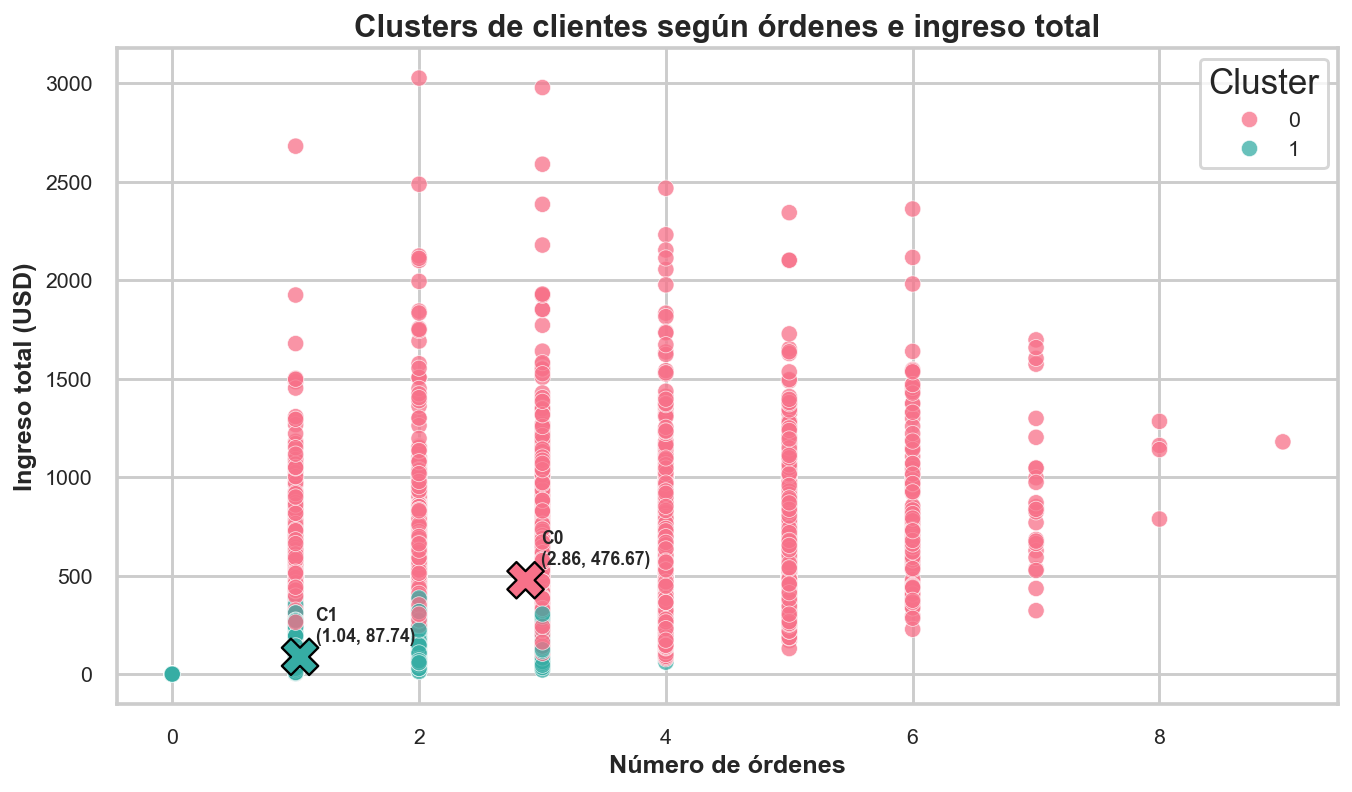

In [56]:
# Grafica los clusters usando ingreso total y número de órdenes como variables interpretables.
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=customer_features,
    x="n_orders",
    y="gross_revenue_usd",
    hue="cluster",
    palette=palette_clusters,
    alpha=0.75,
    s=70,
    edgecolor="white",
    linewidth=0.4
)

# Calcula centroides observables en el espacio original para añadirlos visualmente.
centroids_plot = (
    customer_features
    .groupby("cluster")[["n_orders", "gross_revenue_usd"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=centroids_plot,
    x="n_orders",
    y="gross_revenue_usd",
    hue="cluster",
    palette=palette_clusters,
    s=350,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    legend=False
)

for _, row in centroids_plot.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}\n({row['n_orders']:.2f}, {row['gross_revenue_usd']:.2f})",
        (row["n_orders"], row["gross_revenue_usd"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Clusters de clientes según órdenes e ingreso total")
plt.xlabel("Número de órdenes")
plt.ylabel("Ingreso total (USD)")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("scatter_clusters_ordenes_ingreso.png")
plt.show()

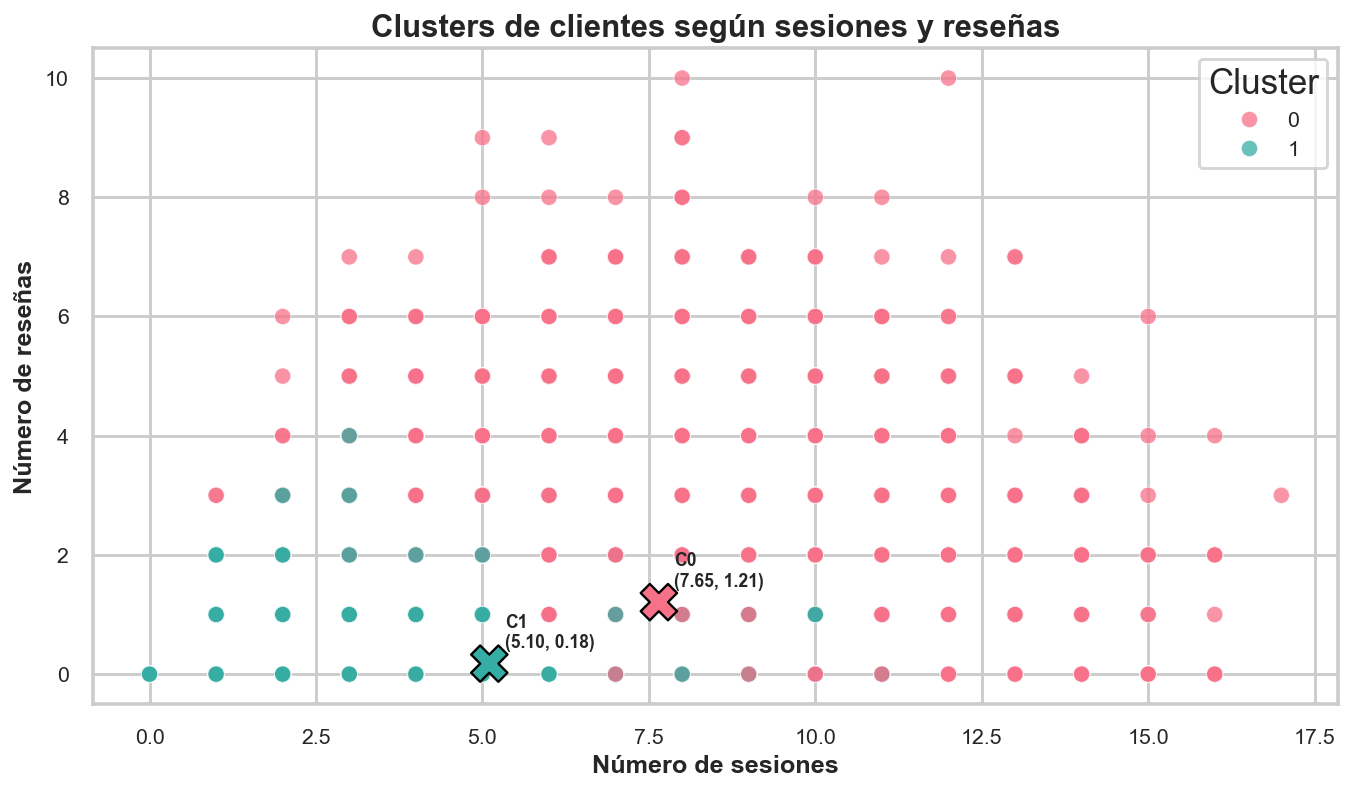

In [57]:
# Grafica los clusters usando sesiones y reseñas para otra vista del comportamiento del cliente.
plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
    data=customer_features,
    x="n_sessions",
    y="n_reviews",
    hue="cluster",
    palette=palette_clusters,
    alpha=0.75,
    s=70,
    edgecolor="white",
    linewidth=0.4
)

centroids_plot_2 = (
    customer_features
    .groupby("cluster")[["n_sessions", "n_reviews"]]
    .mean()
    .reset_index()
)

sns.scatterplot(
    data=centroids_plot_2,
    x="n_sessions",
    y="n_reviews",
    hue="cluster",
    palette=palette_clusters,
    s=350,
    marker="X",
    edgecolor="black",
    linewidth=1.2,
    legend=False
)

for _, row in centroids_plot_2.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}\n({row['n_sessions']:.2f}, {row['n_reviews']:.2f})",
        (row["n_sessions"], row["n_reviews"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Clusters de clientes según sesiones y reseñas")
plt.xlabel("Número de sesiones")
plt.ylabel("Número de reseñas")
plt.legend(title="Cluster")
plt.tight_layout()
save_plot("scatter_clusters_sesiones_resenas.png")
plt.show()

## Interpretación inicial

Los clusters obtenidos representan segmentos de clientes con distintos niveles de actividad, compra y valor económico. La interpretación final debe apoyarse en el tamaño de cada cluster, sus promedios por métrica y la separación observada en los gráficos.

In [58]:
# Muestra el resumen final ordenado por cluster para facilitar interpretación y redacción del informe.
cluster_summary.sort_values("cluster")

,cluster,customers_count,percentage,age,n_sessions,n_orders,gross_revenue_usd,avg_order_value_usd,n_reviews
0,0,7041,35.20,46.97,7.65,2.86,476.67,193.40,1.21
1,1,12959,64.80,46.23,5.10,1.04,87.74,63.35,0.18


## Resultado de esta etapa

En este notebook se aplicó K-Means sobre la tabla `customer_features.csv`, se seleccionó un número de clusters con apoyo del método del codo y silhouette score, y se generaron tablas y gráficos para describir los segmentos de clientes identificados.